In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Set theme seaborn global
sns.set_theme(
    style="whitegrid",
    font="sans-serif",
    rc={
        "figure.figsize": (8, 5),
        "axes.edgecolor": "#EAEAEA",
        "grid.color": "#686D76",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11
    }
)

In [2]:
# dari CSV
df = pd.read_csv("../data/bank_customer_churn.csv")
display(df.head())

memory_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Memory usage: {memory_mb:.2f} MB")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Memory usage: 1.23 MB


In [3]:
print('== Dataset Profile ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')

print('== Missing Values ==')
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Total': missing_count,
    'Percentage(%)': missing_pct
})
missing_summary = missing_summary[missing_summary['Total'] > 0].sort_values(by='Total', ascending=False)
print(missing_summary if not missing_summary.empty else 'No missing values found', '\n')

print('== Duplicate Data ==')
print(f'Total Duplicates : {df.duplicated().sum()}\nDuplicate Percentage : {(df.duplicated().sum()/len(df)*100).round(2)}\n')

print('== Column Data Types ==')
print(df.dtypes)

== Dataset Profile ==
Baris: 10000
Kolom: 14 

== Missing Values ==
No missing values found 

== Duplicate Data ==
Total Duplicates : 0
Duplicate Percentage : 0.0

== Column Data Types ==
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [4]:
cat_cols = df.select_dtypes(include=['object', 'str', 'category']).columns

for col in cat_cols:
    print(f'===== {col} =====\n')
    # 1. Menghitung jumlah total (count)
    counts = df[col].value_counts()
    # 2. Menghitung persentase (percentage)
    percentages = (df[col].value_counts(normalize=True) * 100).map('{:.2f} %'.format)
    # 3. Menggabungkan keduanya menjadi satu DataFrame
    summary_df = pd.concat([counts, percentages], axis=1, keys=['Jumlah', 'PCT'])
    print(summary_df, '\n')

===== Surname =====

                         Jumlah     PCT
Surname                                
Smith                        32  0.32 %
Scott                        29  0.29 %
Martin                       29  0.29 %
Walker                       28  0.28 %
Brown                        26  0.26 %
Shih                         25  0.25 %
Genovese                     25  0.25 %
Yeh                          25  0.25 %
Maclean                      24  0.24 %
Wright                       24  0.24 %
Fanucci                      23  0.23 %
Ma                           23  0.23 %
White                        23  0.23 %
Wilson                       23  0.23 %
Chu                          22  0.22 %
Johnson                      22  0.22 %
Lu                           22  0.22 %
Moore                        22  0.22 %
Wang                         22  0.22 %
Sun                          21  0.21 %
Mai                          21  0.21 %
McGregor                     21  0.21 %
Thompson           

In [5]:
print('== Ringkasan Statistik Kolom Numerik ==')
display(df.describe())
print('\n== Ringkasan Statistik Kolom Kategorikal ==')
display(df.describe(include=['object', 'str', 'category']))

== Ringkasan Statistik Kolom Numerik ==


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



== Ringkasan Statistik Kolom Kategorikal ==


,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


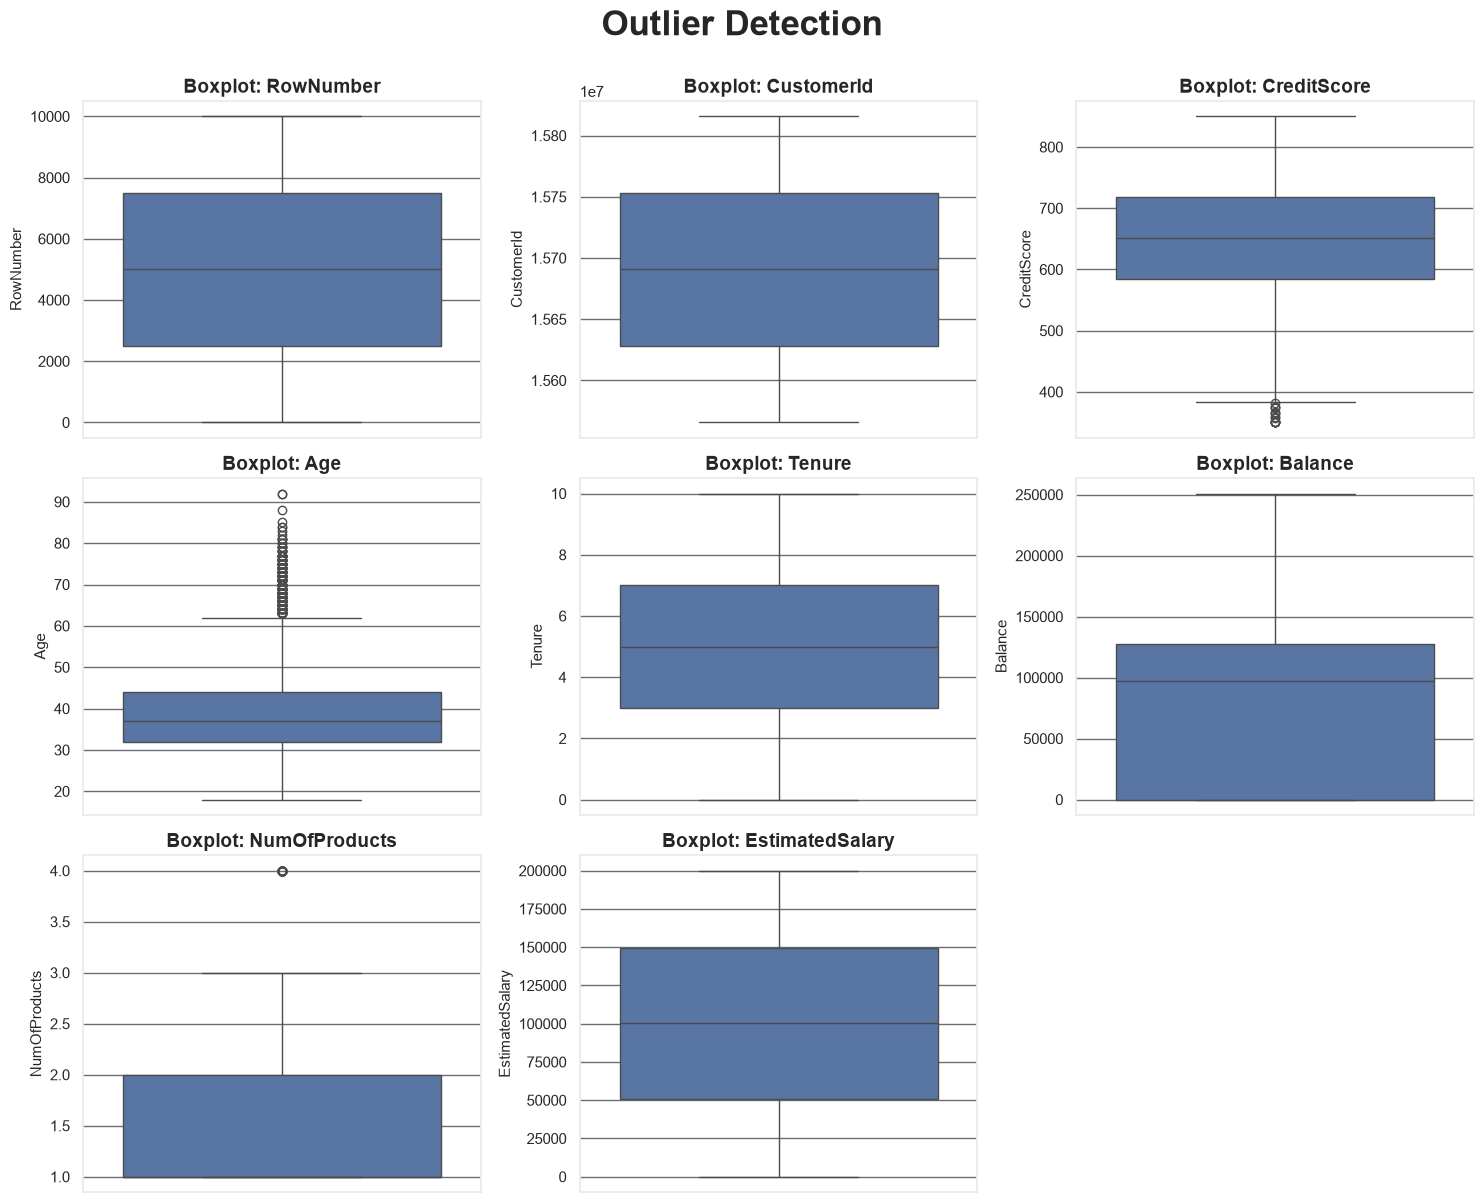

In [6]:
num_cols = df.select_dtypes(include=[int, float]).columns.drop(['HasCrCard', 'IsActiveMember', 'Exited']).tolist()

n_cols = 3
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col], 
        ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")

# hide sisa axes yang kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection", fontsize=25, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

In [7]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

---
# **Visualisations**

Exited
0    7963
1    2037
Name: count, dtype: int64 

Exited
0    79.6 %
1    20.4 %
Name: proportion, dtype: str


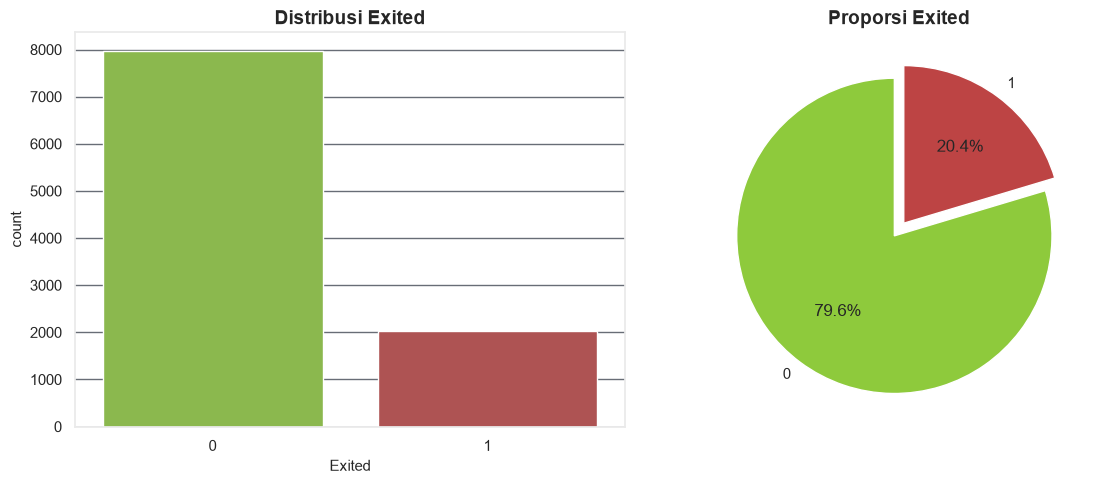

In [8]:
target_col = 'Exited'

print(df[target_col].value_counts(), '\n')
print(df[target_col].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

palette = ['#8ECA3C','#BD4444']
order = df[target_col].value_counts().index.tolist()

# visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# countplot
sns.countplot(
    x=target_col,
    data=df,
    hue=target_col,
    palette=palette,
    legend=False,
    order=order,
    ax=ax[0]
)
ax[0].set_title(f"Distribusi {target_col}")
ax[0].set_xticks([0, 1])

# pie chart
counts = df[target_col].value_counts().reindex(order)
ax[1].pie(
    counts,
    labels=order,
    autopct='%1.1f%%',
    colors=palette,
    startangle=90,
    explode=[0.05, 0.05]
)
ax[1].set_title(f"Proporsi {target_col}")

plt.tight_layout()
plt.savefig('../assets/01_distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

**INSIGHT**<br>
Distribusi imbalance, data didominasi oleh nasabah yang tidak Churn.

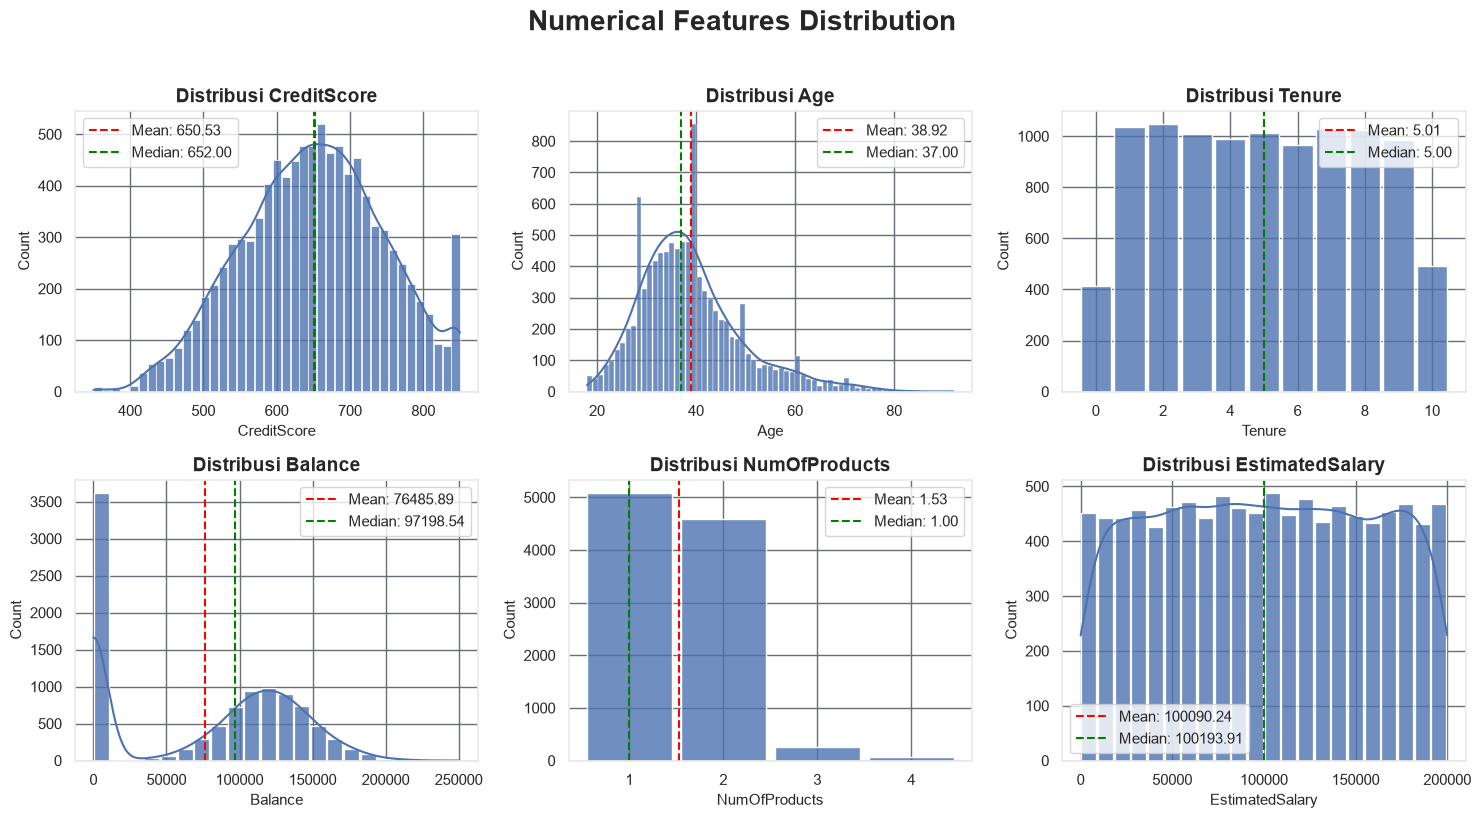

In [9]:
num_cols = df.select_dtypes(include=[int, float]).columns.drop(['HasCrCard', 'IsActiveMember', target_col])

n_cols = 3
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    is_discrete = df[col].nunique() < 20
    sns.histplot(
        data=df,
        x=col,
        kde=not is_discrete,
        discrete=is_discrete,
        alpha=0.8,
        ax=axes[i],
        shrink=0.9
    )
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f'Distribusi {col}')
    axes[i].legend()

# hide sisa axes yang kosong
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Numerical Features Distribution', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/02_distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()

**INSIGHT**<br>
1. **CreditScore**: Berdistribusi normal dengan mean (650.53) dan median (652.00) yang seimbang. Terlihat ada lonjakan di skor maksimal 850.
2. **Age**: Berdistribusi right-skewed. Sebagian besar nasabah berada di usia muda hingga produktif (median 37 tahun, rata-rata 39 tahun), dengan sedikit nasabah di usia lanjut.
3. **Tenure**: Berdistribusi relatif merata untuk rentang 1 hingga 9 tahun. Hanya ada sedikit penurunan signifikan pada masa tenor 0 tahun dan 10 tahun.
4. **Balance**: Distribusi bimodal. Terdapat akumulasi besar nasabah dengan saldo 0 (lebih dari 3500 nasabah), sementara sisanya terdistribusi normal di sekitar angka 100.000 hingga 150.000.
5. **NumOfProducts**: Distribusi distrik yang sangat timpang. Mayoritas nasabah hanya menggunakan 1 atau 2 produk saja (> 90%), sedangkan sisanya berjumlah sedikit.
6. **EstimatedSalary**: Berdistribusi merata. Nasabah tersebar merata di semua tingkatan gaji dari 0 hingga 200.000, dengan nilai rata-rata dan median yang hampir identik (~100.000).

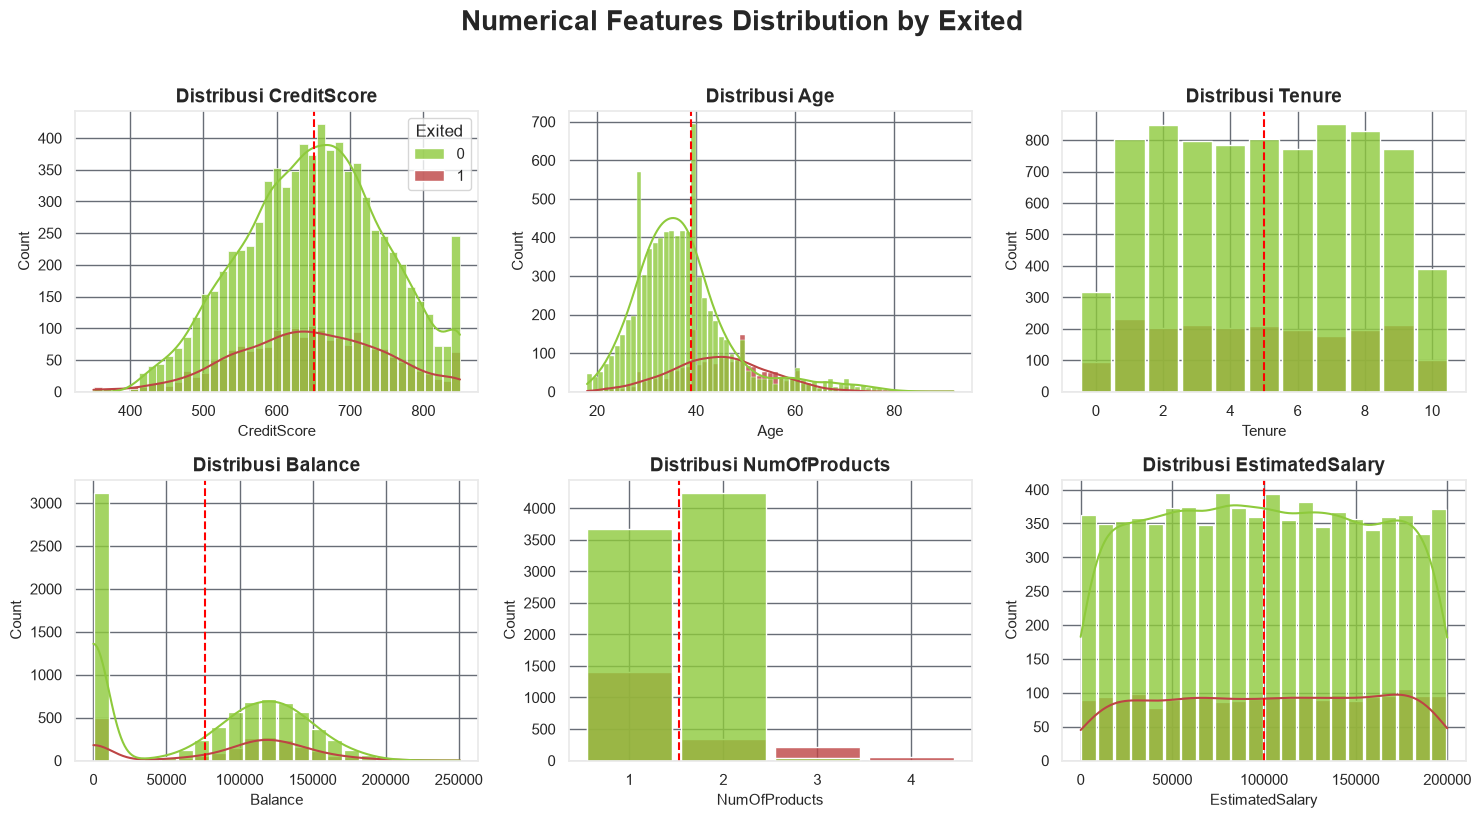

In [10]:
target_col = 'Exited'
num_cols = df.select_dtypes(include=[int, float]).columns.drop(['HasCrCard', 'IsActiveMember', target_col])

n_cols = 3
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    is_discrete = df[col].nunique() < 20
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        palette=palette,
        kde=not is_discrete,
        discrete=is_discrete,
        alpha=0.8,
        ax=axes[i],
        shrink=0.9,
        legend=(i == 0)       # legend di chart pertama
    )
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].set_title(f'Distribusi {col}')

# hide sisa axes yang kosong
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Numerical Features Distribution by {target_col}', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/03_distribusi_numerik_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

**INSIGHT**<br>
1. **CreditScore**: Distribusi untuk kedua kelompok cukup mirip dan overlapping. Namun, terlihat sedikit peningkatan proporsi churn pada nasabah dengan credit score yang rendah (< 400).
2. **Age**: Nasabah yang churn cenderung berusia lebih tua (puncaknya di kisaran 40-50+ tahun), sedangkan nasabah yang bertahan didominasi oleh usia muda (30-40 tahun).
3. **Tenure**: Proporsi churn relatif stabil dan merata dari masa tenor 0 hingga 10 tahun.
4. **Balance**: Nasabah yang churn terkonsentrasi di saldo mengngah hingga tinggi (100.000 - 150.000)
5. **NumOfProducts**: Nasabah dengan 1 produk memiliki tingkat churn yang tergolong tinggi. Namun, nasabah dengan 3 atau 4 produk hampir seluruhnya melakukan churn.
6. **EstimatedSalary**: Estimasi gaji tidak memiliki pengaruh langsung terhadap churn. Distribusi sama-sama merata.

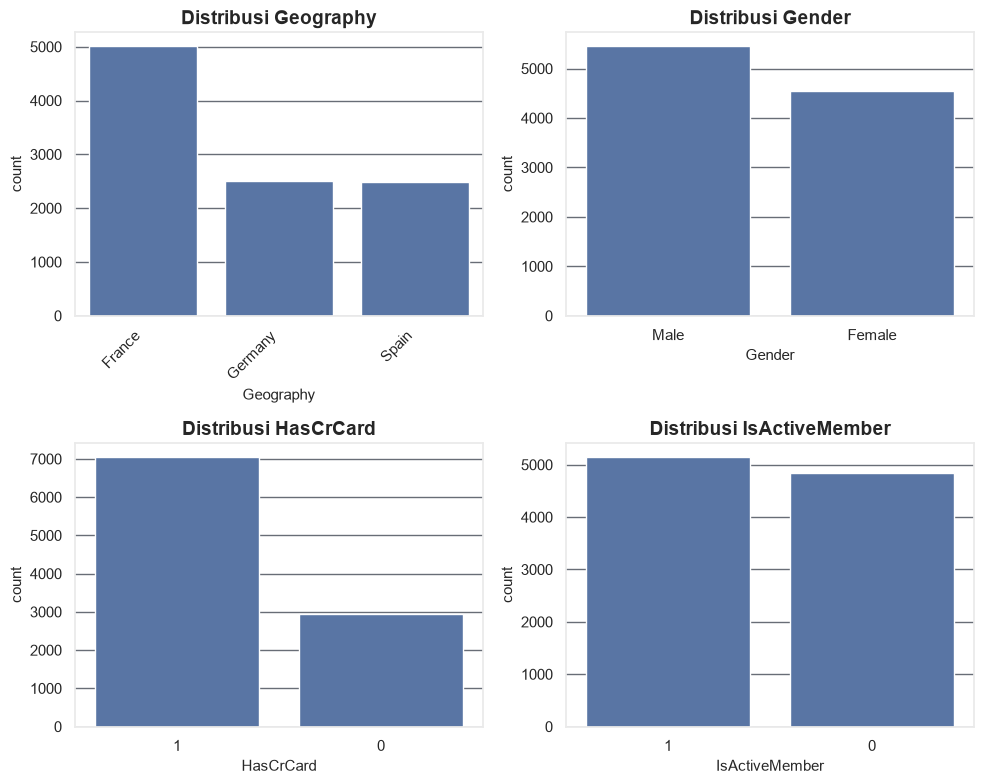

In [11]:
# Deteksi kolom kategorikal: object/category + numerik dengan sedikit unique value

cat_cols = df.select_dtypes(include=['object', 'str', 'category']).columns.tolist()
num_cat_cols = [col for col in df.select_dtypes(include=[int, float]).columns
                if df[col].nunique() <= 3 and col != target_col]
cat_cols = [c for c in cat_cols + num_cat_cols if c != target_col]

n_cols = 2
n_rows = -(-len(cat_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        x=df[col], 
        order=df[col].value_counts().index, 
        ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    max_len = df[col].dropna().apply(lambda x: len(str(x))).max()
    if max_len > 6:
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')
    else:
        plt.setp(axes[i].get_xticklabels(), rotation=0, ha='center')

for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../assets/04_distribusi_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("="*30 + f"\nTABEL FREKUENSI KATEGORIKAL\n" + "="*30)

for col in cat_cols:
    tab = pd.DataFrame({
        'count': df[col].value_counts(dropna=False),
        'percentage': df[col].value_counts(normalize=True, dropna=False).mul(100).round(1).astype(str) + ' %'
    })
    print(f"\n=== {col} ===")
    display(tab)

TABEL FREKUENSI KATEGORIKAL

=== Geography ===


,count,percentage
Geography,,
France,5014,50.1 %
Germany,2509,25.1 %
Spain,2477,24.8 %



=== Gender ===


,count,percentage
Gender,,
Male,5457,54.6 %
Female,4543,45.4 %



=== HasCrCard ===


,count,percentage
HasCrCard,,
1,7055,70.6 %
0,2945,29.4 %



=== IsActiveMember ===


,count,percentage
IsActiveMember,,
1,5151,51.5 %
0,4849,48.5 %


**INSIGHT**<br>
1. **Geography**: Separuh dari total nasabah (50%) berasal dari France. Sisa nasabah terbagi secara seimbang antara Germany (25.1%) dan spain (24.8%).
2. **Gender**: Proporsi nasabah tergolong relatif seimbang tetapi didominasi oleh laki-laki sebesar 54.6%, sedangkan perempuan 45.4%.
3. **HasCrCard**: Mayoritas nasabah sudah memiliki kartu kredit (70.6%), sisanya 29.4% belum punya.
4. **IsActiveMember**: Proporsi keaktifan nasabah sangat seimbang, dengan nasabah yang aktif sedikit lebih banyak di 51.5%.

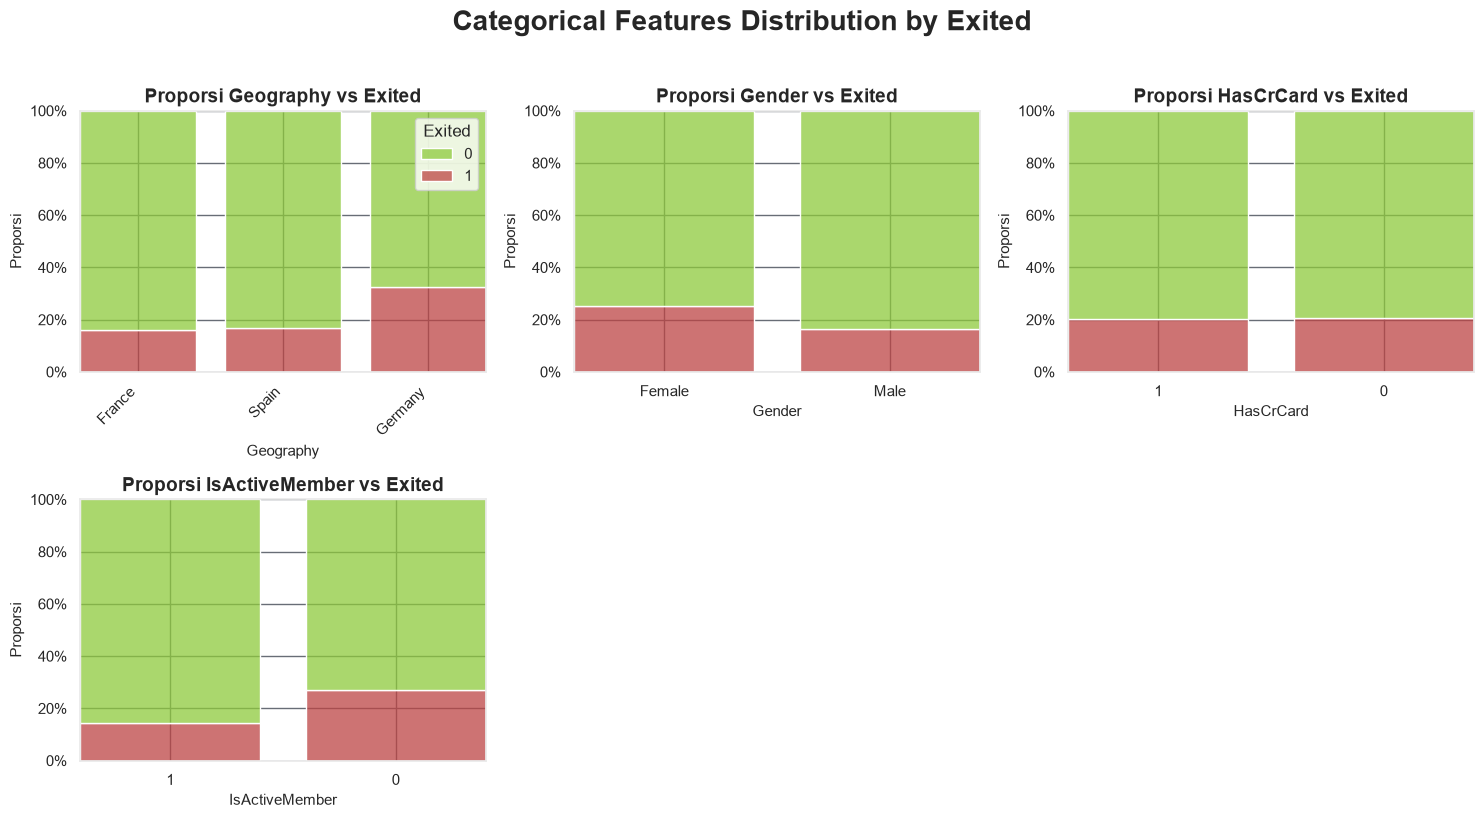

In [13]:
import matplotlib.ticker as mtick

target_col = 'Exited'
palette = ['#8ECA3C', '#BD4444']
order = [0, 1]

cat_cols = df.select_dtypes(include=['object', 'str', 'category']).columns.tolist()
num_cat_cols = [col for col in df.select_dtypes(include=[int, float]).columns
                if df[col].nunique() <= 3 and col != target_col]
cat_cols = [c for c in cat_cols + num_cat_cols if c != target_col]

# VISUALISASI PROPORSI
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_df = df.assign(**{col: df[col].astype(str)})
    sns.histplot(
        data=plot_df,
        x=col,
        hue=target_col,
        multiple="fill",
        palette=palette,
        ax=axes[i],
        shrink=0.8,
        hue_order=order,
        legend=(i == 0)
    )
    axes[i].set_title(f'Proporsi {col} vs {target_col}')
    axes[i].set_ylabel('Proporsi')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    max_len = plot_df[col].dropna().apply(lambda x: len(str(x))).max()
    if max_len > 6:
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')
    else:
        plt.setp(axes[i].get_xticklabels(), rotation=0, ha='center')

for ax in axes[len(cat_cols):]:
    ax.axis('off')

plt.suptitle(f'Categorical Features Distribution by {target_col}', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/05_distribusi_kategorikal_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("="*50 + f"\nTABEL FREKUENSI & PROPORSI BERDASARKAN {target_col.upper()}\n" + "="*50)

for col in cat_cols:
    ct = pd.crosstab(df[col], df[target_col])
    ct_pct = pd.crosstab(df[col], df[target_col], normalize='index').mul(100).round(1)
    ct_combined = ct.astype(str) + " (" + ct_pct.astype(str) + "%)"
    display(ct_combined.style.set_caption(f"Distribusi {col} vs {target_col}"))

TABEL FREKUENSI & PROPORSI BERDASARKAN EXITED


Exited,0,1
Geography,,
France,4204 (83.8%),810 (16.2%)
Germany,1695 (67.6%),814 (32.4%)
Spain,2064 (83.3%),413 (16.7%)


Exited,0,1
Gender,,
Female,3404 (74.9%),1139 (25.1%)
Male,4559 (83.5%),898 (16.5%)


Exited,0,1
HasCrCard,,
0,2332 (79.2%),613 (20.8%)
1,5631 (79.8%),1424 (20.2%)


Exited,0,1
IsActiveMember,,
0,3547 (73.1%),1302 (26.9%)
1,4416 (85.7%),735 (14.3%)


**INSIGHT**<br>
1. **Geography**: Germany memiliki persentase churn paling tinggi di 32.4%, 2x lipat lebih tinggi dibanding negara lain.
2. **Gender**: Nasabah female menunjukkan kecenderungan churn lebih tinggi (di 25.1%) dibanding male.
3. **HasCrCard**: Tingkat churn nasabah yang memiliki kartu kredit (20.2%) hampir sama dengan yang tidak memilikinya (20.8%).
4. **IsActiveMember**: Keaktifan nasabah terbukti menekan angka churn. Nasabah yang tidak aktif memilki tingkat churn yang lebih tinggi (di 26.9%) dibandingkan yang aktif (14.3%).

Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64 



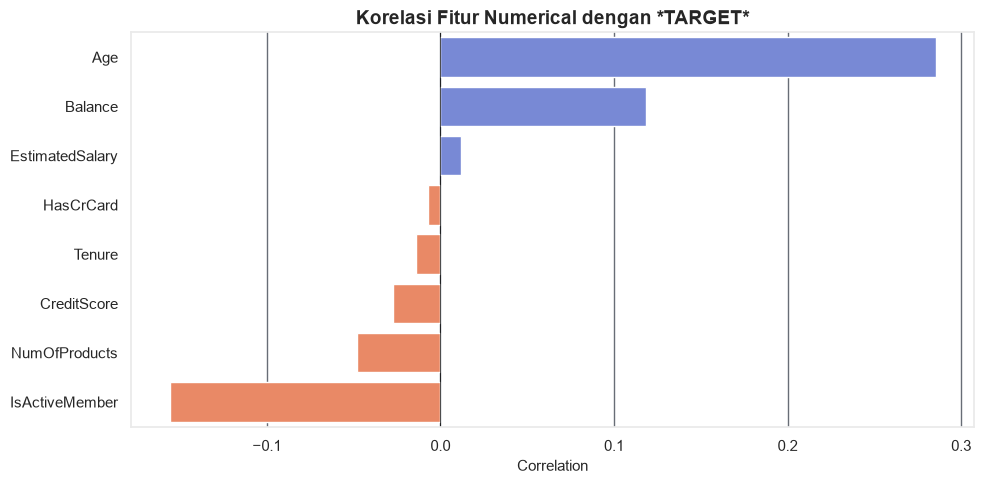

In [15]:
num_cols = df.select_dtypes(include=[int, float]).columns.tolist()
corr_bar = df[num_cols].corr()[target_col].sort_values(ascending=False).drop(target_col)
print(corr_bar, '\n')

plt.figure(figsize=(10, 5))
sns.barplot(
    x=corr_bar.values, 
    y=corr_bar.index,
    hue=corr_bar.index,
    palette=['#687FE5' if x > 0 else 'coral' for x in corr_bar.values]
)
plt.title('Korelasi Fitur Numerical dengan *TARGET*')
plt.xlabel('Correlation')
plt.ylabel('')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../assets/06_korelasi_bar_numerik_target.png', dpi=150, bbox_inches='tight')
plt.show()

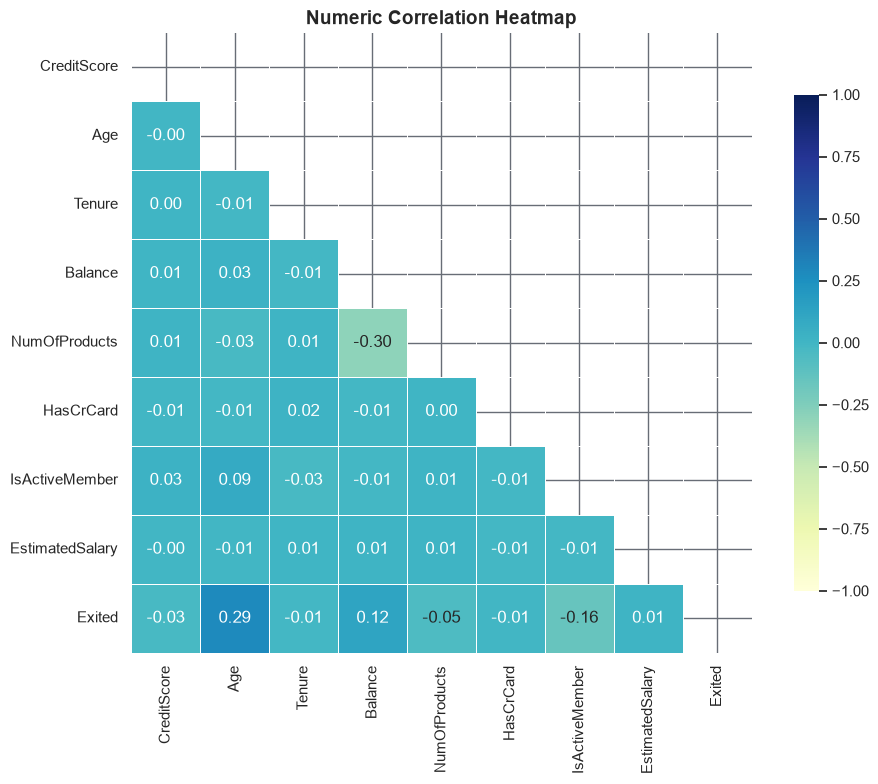

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

num_cols = df.select_dtypes(include=[int, float]).columns.tolist()
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.5, 
    ax=ax,
    cbar_kws={'shrink': 0.8})

ax.set_title('Numeric Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **Save Data**

In [17]:
df.reset_index(drop=True, inplace=True)

# cek hasil akhir
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')
df.info()
df.isnull().sum()

# simpan ke CSV
df.to_csv('../data/CLEAN_bank_customer_churn.csv', index=False)

Baris: 10000
Kolom: 11 

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [18]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
